In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

plt.style.use('dark_background')
ACCENT = '#38bdf8'
RED    = '#f87171'
GREEN  = '#34d399'
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Inspect Dataset

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [4]:
print('Class Distribution:')
vc = df['Class'].value_counts()
print(vc)
print(f'\nFraud %: {vc[1]/len(df)*100:.4f}%')

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727%


## 2. Exploratory Data Analysis

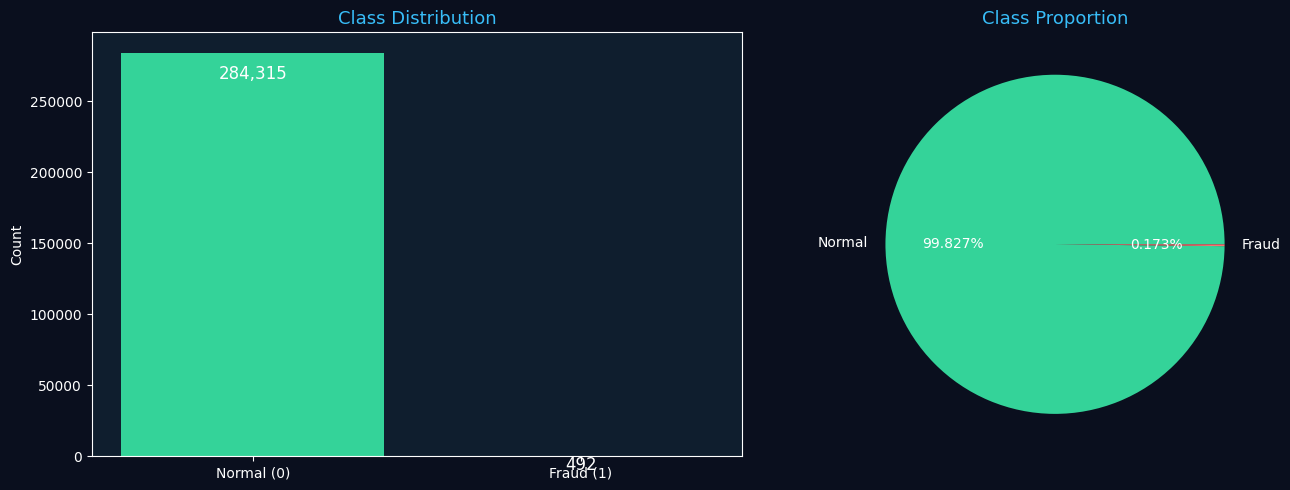

In [5]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0f1e')

# Bar chart
ax = axes[0]
ax.set_facecolor('#0f1e2e')
bars = ax.bar(['Normal (0)', 'Fraud (1)'], vc.values,
              color=[GREEN, RED], edgecolor='none')
ax.set_title('Class Distribution', color=ACCENT, fontsize=13)
ax.set_ylabel('Count', color='white')
ax.tick_params(colors='white')
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.97,
            f'{val:,}', ha='center', va='top', color='white', fontsize=12)

# Pie chart
ax = axes[1]
ax.set_facecolor('#0f1e2e')
ax.pie(vc.values, labels=['Normal', 'Fraud'],
       colors=[GREEN, RED], autopct='%1.3f%%',
       textprops={'color': 'white'})
ax.set_title('Class Proportion', color=ACCENT, fontsize=13)

plt.tight_layout()
plt.show()

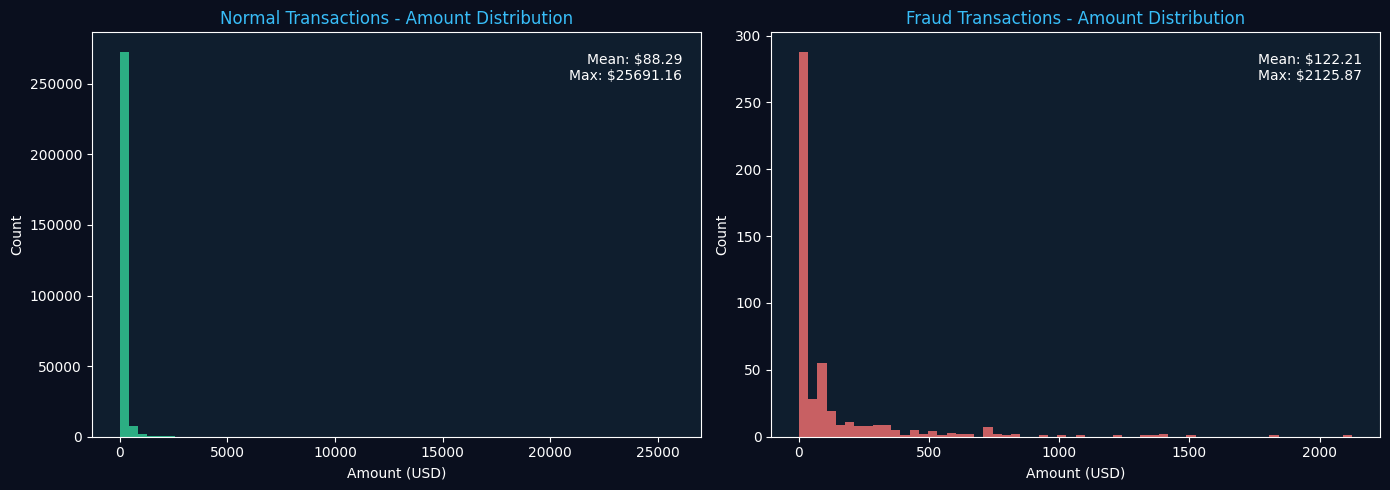

In [6]:
# Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0f1e')

normal_amt = df[df['Class'] == 0]['Amount']
fraud_amt  = df[df['Class'] == 1]['Amount']

for ax, data, color, label in [
    (axes[0], normal_amt, GREEN, 'Normal Transactions'),
    (axes[1], fraud_amt,  RED,   'Fraud Transactions')
]:
    ax.set_facecolor('#0f1e2e')
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f'{label} - Amount Distribution', color=ACCENT, fontsize=12)
    ax.set_xlabel('Amount (USD)', color='white')
    ax.set_ylabel('Count', color='white')
    ax.tick_params(colors='white')
    ax.text(0.97, 0.95, f'Mean: ${data.mean():.2f}\nMax: ${data.max():.2f}',
            transform=ax.transAxes, ha='right', va='top',
            color='white', fontsize=10)

plt.tight_layout()
plt.show()

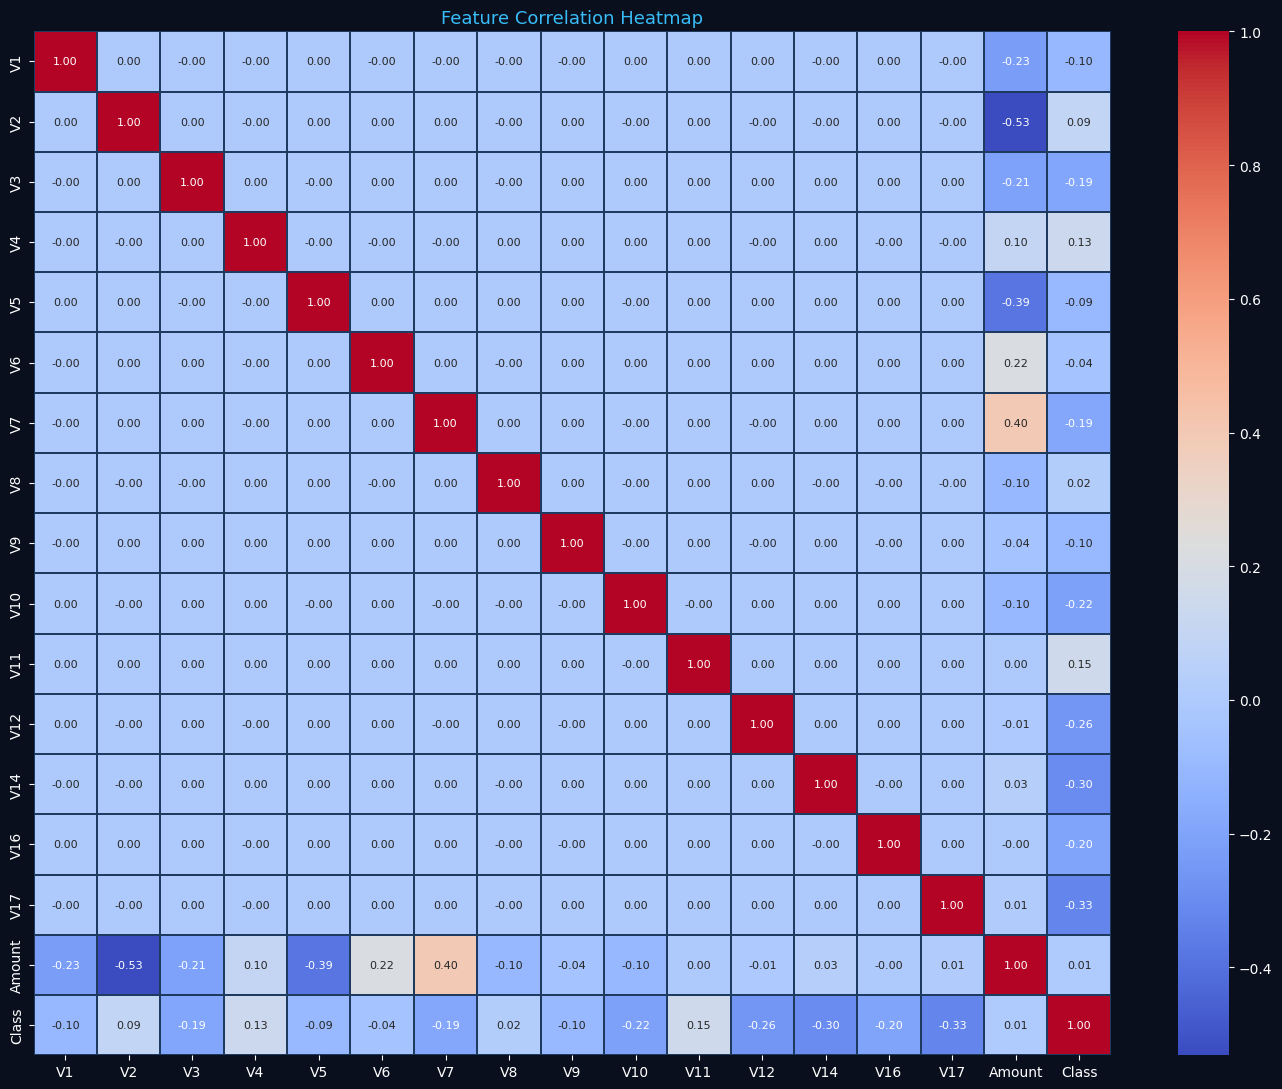

In [7]:
# Correlation heatmap (top V features)
top_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                'V11','V12','V14','V16','V17','Amount','Class']
corr = df[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#0a0f1e')
ax.set_facecolor('#0f1e2e')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.3, linecolor='#1e3a5f',
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', color=ACCENT, fontsize=13)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

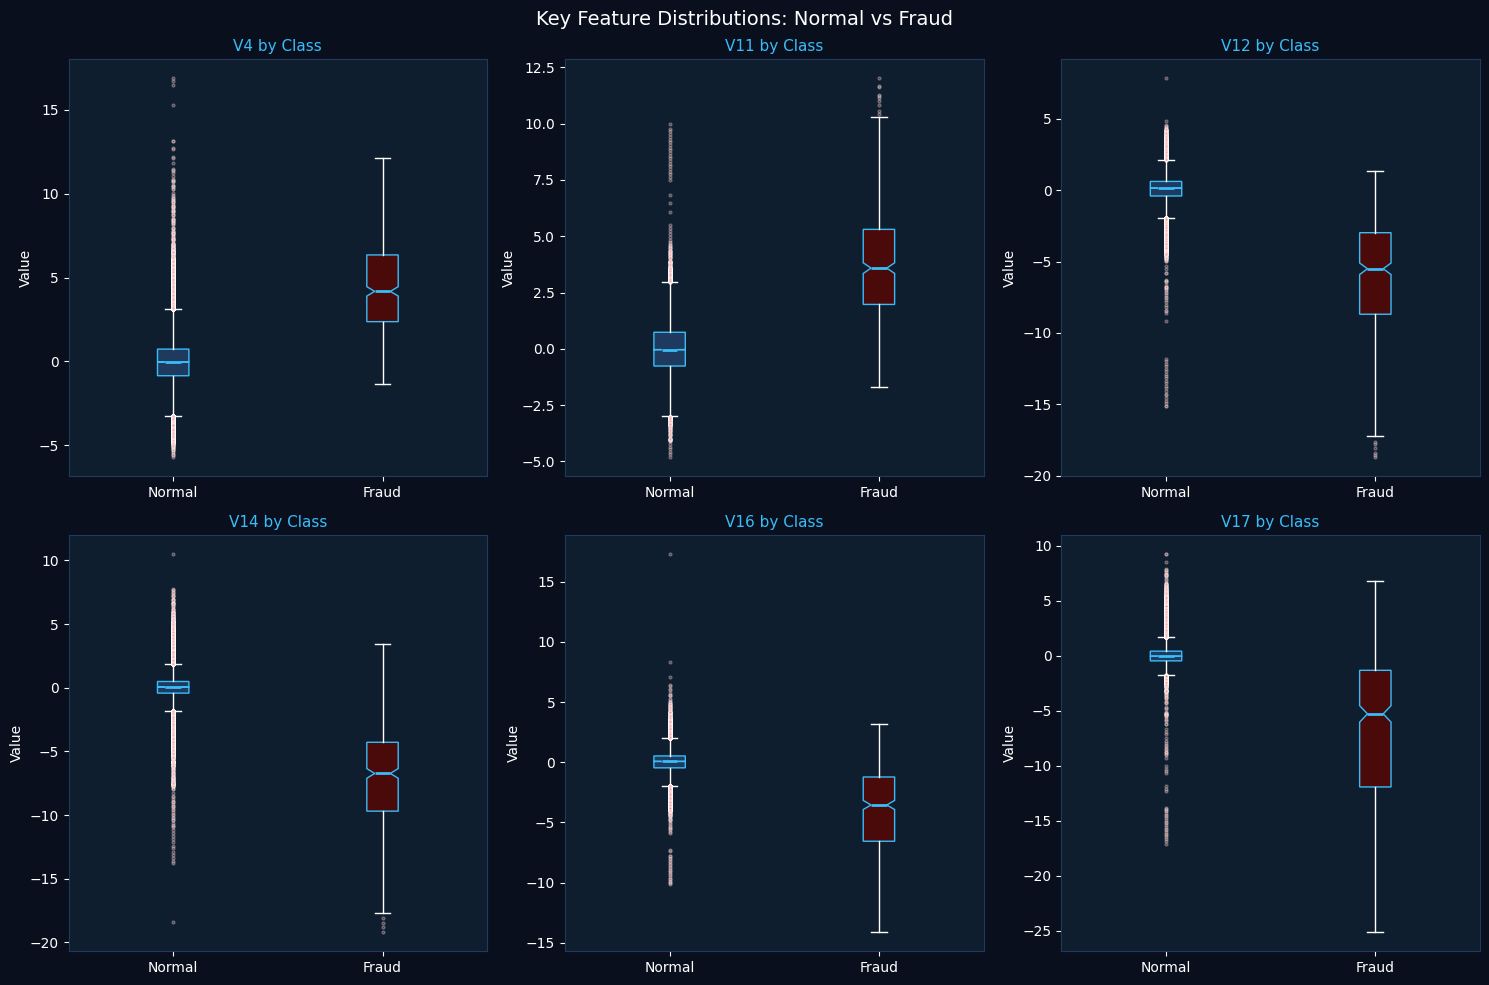

In [8]:
# Box plots of key V-features by class
key_features = ['V4', 'V11', 'V12', 'V14', 'V16', 'V17']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('#0a0f1e')
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    ax.set_facecolor('#0f1e2e')
    data = [df[df['Class']==0][feat].values, df[df['Class']==1][feat].values]
    bp = ax.boxplot(data, patch_artist=True, notch=True,
                    boxprops=dict(facecolor='#1e3a5f', color=ACCENT),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    medianprops=dict(color=ACCENT, linewidth=2),
                    flierprops=dict(markerfacecolor=RED, markersize=2, alpha=0.3))
    bp['boxes'][1].set(facecolor='#4a0a0a')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Normal', 'Fraud'], color='white')
    ax.tick_params(colors='white')
    ax.set_title(f'{feat} by Class', color=ACCENT, fontsize=11)
    ax.set_ylabel('Value', color='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a5f')

plt.suptitle('Key Feature Distributions: Normal vs Fraud', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [9]:
df_proc = df.drop(columns=['Time'])
y = df_proc['Class'].values
X = df_proc.drop(columns=['Class']).values.astype(np.float32)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X shape: {X_scaled.shape}')
print(f'y shape: {y.shape}')
print(f'Normal: {(y==0).sum():,}  |  Fraud: {(y==1).sum():,}')

X shape: (284807, 29)
y shape: (284807,)
Normal: 284,315  |  Fraud: 492


## 4. Train Isolation Forest

In [10]:
contamination = round((y==1).sum() / len(y), 4)
print(f'Contamination: {contamination}')

iso = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
iso.fit(X_scaled)
print('Model trained!')

Contamination: 0.0017
Model trained!


In [11]:
raw_pred = iso.predict(X_scaled)
y_pred   = np.where(raw_pred == -1, 1, 0)
scores   = iso.decision_function(X_scaled)

print('Classification Report:')
print(classification_report(y, y_pred, target_names=['Normal','Fraud']))

roc = roc_auc_score(y, -scores)
print(f'ROC-AUC: {roc:.4f}')

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.28      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807

ROC-AUC: 0.9482


## 5. Visualise Results

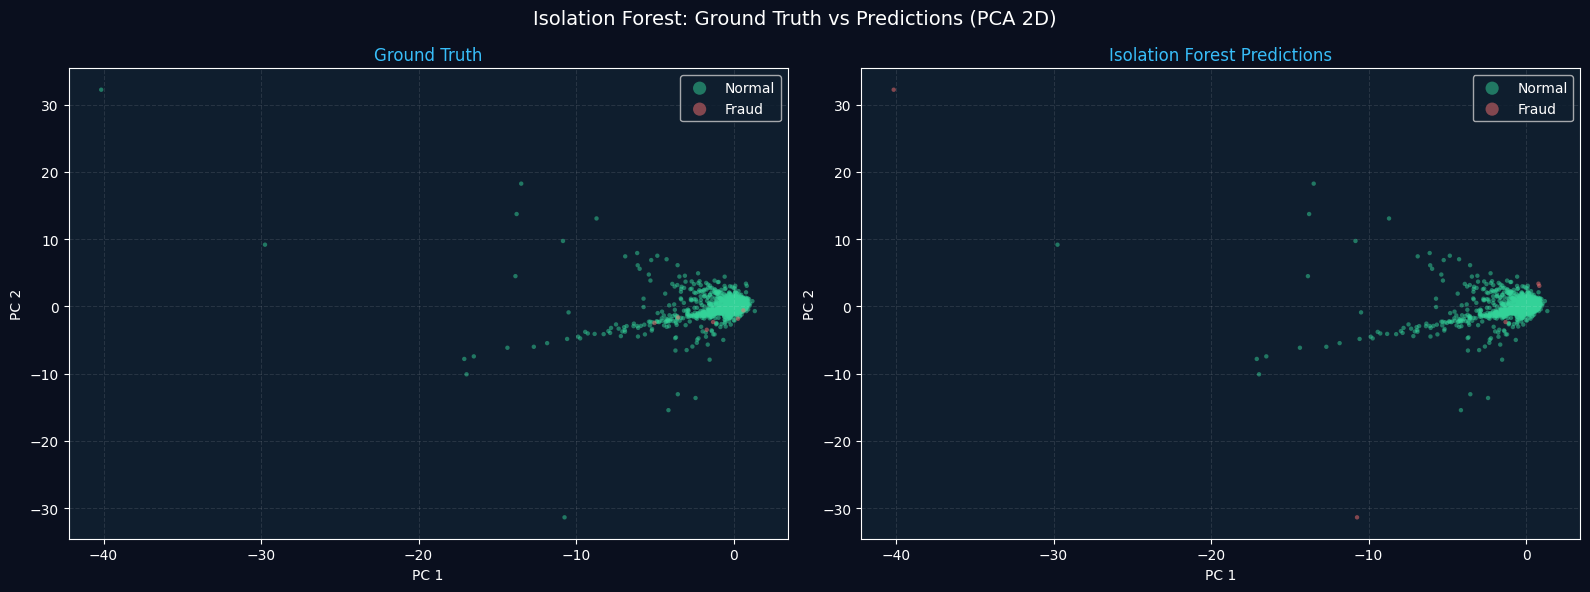

In [12]:
# PCA 2D scatter
N_VIZ = 5000
np.random.seed(42)
idx_v = np.random.choice(len(X_scaled), N_VIZ, replace=False)
pca2  = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled[idx_v])
y_v   = y[idx_v]
p_v   = y_pred[idx_v]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0a0f1e')

for ax, labels, title in [
    (axes[0], y_v,  'Ground Truth'),
    (axes[1], p_v,  'Isolation Forest Predictions')
]:
    ax.set_facecolor('#0f1e2e')
    for cls, c, l in [(0, GREEN, 'Normal'), (1, RED, 'Fraud')]:
        m = labels == cls
        ax.scatter(X_pca[m,0], X_pca[m,1], c=c, label=l,
                   alpha=0.5, s=10, edgecolors='none')
    ax.set_title(title, color=ACCENT, fontsize=12)
    ax.set_xlabel('PC 1', color='white'); ax.set_ylabel('PC 2', color='white')
    ax.tick_params(colors='white')
    ax.legend(facecolor='#0f1e2e', labelcolor='white', markerscale=3)
    ax.grid(True, linestyle='--', alpha=0.1)

plt.suptitle('Isolation Forest: Ground Truth vs Predictions (PCA 2D)',
             color='white', fontsize=14)
plt.tight_layout()
plt.show()

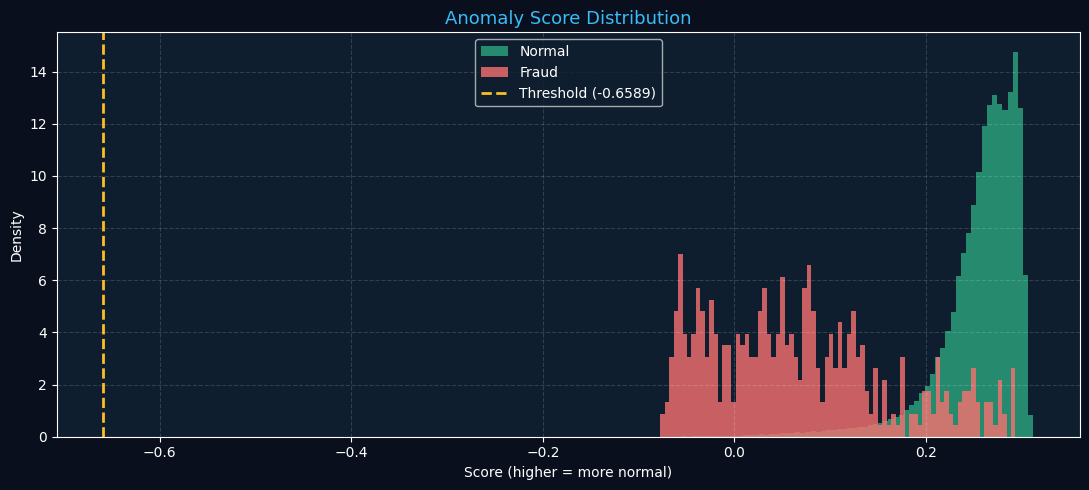

In [13]:
# Score distribution
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0a0f1e')
ax.set_facecolor('#0f1e2e')

ax.hist(scores[y==0], bins=80, color=GREEN, alpha=0.6, label='Normal', density=True)
ax.hist(scores[y==1], bins=80, color=RED,   alpha=0.8, label='Fraud',  density=True)
ax.axvline(iso.offset_, color='#fbbf24', linewidth=2, linestyle='--',
           label=f'Threshold ({iso.offset_:.4f})')

ax.set_title('Anomaly Score Distribution', color=ACCENT, fontsize=13)
ax.set_xlabel('Score (higher = more normal)', color='white')
ax.set_ylabel('Density', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#0f1e2e', labelcolor='white')
ax.grid(True, linestyle='--', alpha=0.15)
plt.tight_layout()
plt.show()

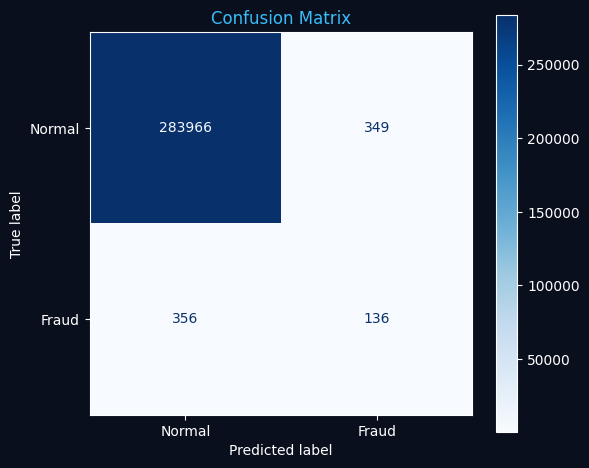

In [14]:
# Confusion matrix
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0a0f1e')
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_facecolor('#0f1e2e')
ax.set_title('Confusion Matrix', color=ACCENT)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
plt.tight_layout()
plt.show()

## 6. Hyperparameter: Effect of n_estimators

n_estimators= 10  F1=0.2471
n_estimators= 50  F1=0.2272
n_estimators=100  F1=0.2845
n_estimators=200  F1=0.2784
n_estimators=300  F1=0.2968


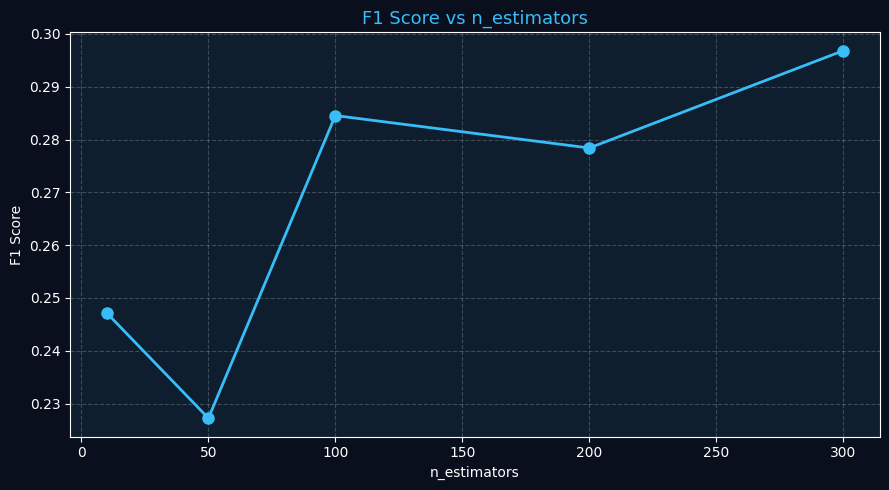

In [15]:
estimator_counts = [10, 50, 100, 200, 300]
f1_scores = []

for n in estimator_counts:
    m = IsolationForest(n_estimators=n, contamination=contamination,
                        random_state=42, n_jobs=-1)
    m.fit(X_scaled)
    p = np.where(m.predict(X_scaled) == -1, 1, 0)
    f1_scores.append(f1_score(y, p, zero_division=0))
    print(f'n_estimators={n:3d}  F1={f1_scores[-1]:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a0f1e')
ax.set_facecolor('#0f1e2e')
ax.plot(estimator_counts, f1_scores, color=ACCENT, linewidth=2, marker='o', markersize=8)
ax.set_title('F1 Score vs n_estimators', color=ACCENT, fontsize=13)
ax.set_xlabel('n_estimators', color='white')
ax.set_ylabel('F1 Score', color='white')
ax.tick_params(colors='white')
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Summary

In [16]:
from sklearn.metrics import precision_score, recall_score

print('=' * 50)
print('ISOLATION FOREST - FINAL RESULTS')
print('=' * 50)
print(f'Dataset     : Credit Card Fraud Detection')
print(f'Total rows  : {len(y):,}')
print(f'Fraud rows  : {(y==1).sum():,}  ({(y==1).sum()/len(y)*100:.4f}%)')
print(f'n_estimators: 200')
print(f'Contamination: {contamination}')
print(f'Precision   : {precision_score(y, y_pred):.4f}')
print(f'Recall      : {recall_score(y, y_pred):.4f}')
print(f'F1 Score    : {f1_score(y, y_pred):.4f}')
print(f'ROC-AUC     : {roc:.4f}')
print('=' * 50)

ISOLATION FOREST - FINAL RESULTS
Dataset     : Credit Card Fraud Detection
Total rows  : 284,807
Fraud rows  : 492  (0.1727%)
n_estimators: 200
Contamination: 0.0017
Precision   : 0.2804
Recall      : 0.2764
F1 Score    : 0.2784
ROC-AUC     : 0.9482
